In [1]:
import pandas as pd
import glob

cols = ['open_time','open','high','low','close','volume',
        'close_time','quote_volume','trades','taker_buy_base',
        'taker_buy_quote','ignore']

BASE = '/home/onyxia/work/binance-public-data/python/data/spot/monthly/klines'

def load_symbol(symbol):
    files = sorted(glob.glob(f'{BASE}/{symbol}/1h/**/*.zip', recursive=True))
    print(f"{symbol}: {len(files)} fichiers trouvés")
    dfs = [pd.read_csv(f, names=cols) for f in files]
    df = pd.concat(dfs, ignore_index=True)

    t = pd.to_numeric(df['open_time'], errors='coerce')
    df = df[t.notna()]
    t = t[t.notna()]
    t = (t / 1000).where(t > 1e14, t)
    df['open_time'] = pd.to_datetime(t, unit='ms')

    df = df.set_index('open_time').sort_index()
    return df['close'].astype(float).rename(symbol)

btc = load_symbol('BTCUSDT')
eth = load_symbol('ETHUSDT')
sol = load_symbol('SOLUSDT')


prices = pd.concat([btc, eth, sol], axis=1).dropna().reset_index()
print(prices.shape)

BTCUSDT: 6 fichiers trouvés
ETHUSDT: 6 fichiers trouvés
SOLUSDT: 6 fichiers trouvés
(4344, 4)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from GARCH_pipeline import *

In [3]:
prices['Δ_log_BTC'] = np.log(prices['BTCUSDT']).diff()
prices = prices.dropna(subset=['Δ_log_BTC'])

Sur 4343 périodes avec comme paramètres θ= (phi0 = 3.22778406e-05, phi1 = -0.0456593195, alpha0 = 1.32843343e-06, alpha1 = 0.183254046, beta0 = 0.77144728, v=3.43619742, y=0.0790732411, loi=student,


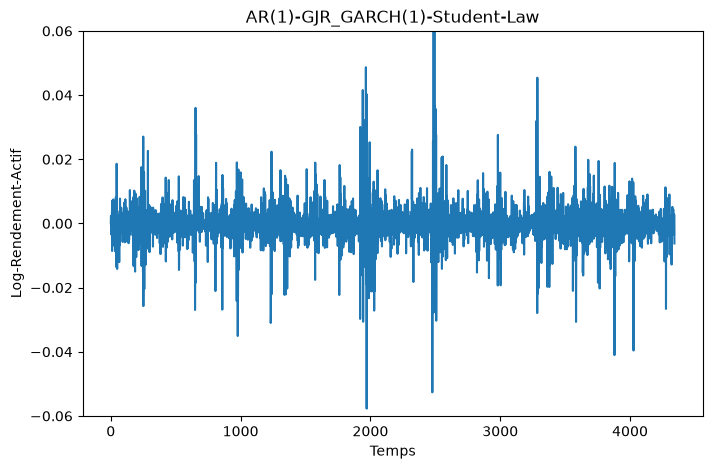

(array([ 0.        ,  0.00232283,  0.00233013, ...,  0.00258057,
        -0.00181839, -0.00636209], shape=(4343,)),
 array([ 3.08684100e-05,  2.35370015e-03,  2.25494046e-03, ...,
         2.77705319e-03, -1.91290983e-03, -6.24246677e-03], shape=(4343,)))

In [4]:
#bien revoir les conditions qui permettent variance d'être définie et de la stationnarité
n=prices['Δ_log_BTC'].count()

phi0=3.22778406e-05
phi1=-4.56593195e-02
alpha0=1.32843343e-06
alpha1=1.83254046e-01
beta0=7.71447280e-01 #Si ARCH et non GARCH, mettre beta0=0
v=3.43619742e+00 #Si loi normal, paramètre inutile, mettre v=0
y=7.90732411e-02 #Si GARCH/ARCH et non GJR_GARCH, mettre y=0
loi='student'

AR_GJR_GARCH_student(n,phi0,phi1,alpha0,alpha1,beta0,v,y,loi)

In [7]:
actif=prices['Δ_log_BTC'].to_numpy()
parametres_initiaux=[phi0,phi1,alpha0,alpha1,beta0,v,y]
loi='student'

opti_AR_GJR_GARCH_student(parametres_initiaux,actif,loi)

Paramètres optimaux : [ 3.20671161e-05 -4.56135991e-02  1.32830654e-06  1.83192108e-01
  7.71504274e-01  3.43594839e+00  7.90687540e-02]
Succès de la convergence : True
